# What does p-value mean?

In [1]:
from random import sample
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
import seaborn as sns
from scipy.stats import norm

A factory claims their bags of coffee beans weigh exactly 250 grams. You think they are not being honest. And take a sample.

In [2]:
mu_null = 250
sample_mean = 245
n = 36

You find that sample mean is 245 grams, is it enough to say that factory is lying?

In [3]:
pop_std = 12

Because we know the population standard deviation, we can easily calculate the sampling distribution of the sample mean.

In [4]:
std_err = pop_std / np.sqrt(n)

The key point here is that we proceed with our calculations by assuming $H_0$ is true, in a sense, we begin our reasoning with the phrase “If $H_0$ were true...”.

That is, regarding the confidence interval, we construct the normal distribution graph using the sample and its mean (since we are already discussing a specific level of confidence, within this context we placed $\bar{x}$ exactly at the center of the sampling distribution of the means), but here we construct it based on $\mu_0$.

In [5]:
z_score = (sample_mean - mu_null) / std_err
z_score

np.float64(-2.5)

For this reason, we substitute $\mu_0$ for $\mu$ in the z-score formula and perform our calculations.

We found that it lies at a distance of $-2.5\sigma$. However, since this is a two-tailed test, that is, the question asks whether it differs from 250, we need to calculate the z-scores for both 245 and 255 ($250\pm5$). Although the sample mean we found indicates how much smaller the true $\mu$ value could be than 250, if we are only considering the difference, we also need to determine how much larger it could be. In other words, we are proceeding under the premise that the spread could occur in either direction.

In [6]:
null_distribution = norm(loc=mu_null, scale=std_err)

In [7]:
p_value = 2 * null_distribution.cdf(sample_mean)
p_value

np.float64(0.012419330651552265)

Here, we found a p-value and multiplied it by 2, using the CDF of a normal distribution in the process. To understand why we did this, we first need to look at the PDF. So let’s see the visualization.

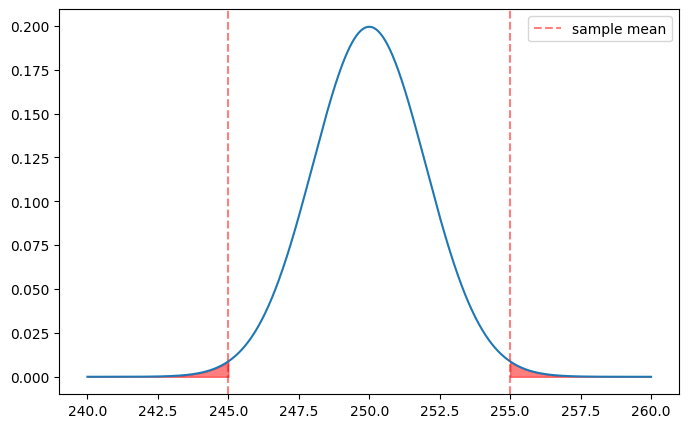

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.linspace(240, 260, 1000)
ax.plot(x, null_distribution.pdf(x))
ax.axvline(sample_mean, color="red", label="sample mean", linestyle="--", alpha=0.5)
ax.axvline(
    (mu_null + (mu_null - sample_mean)),
    color="red",
    linestyle="--",
    alpha=0.5,
)

x_left_tail = np.linspace(240, sample_mean, 100)
x_right_tail = np.linspace((mu_null + (mu_null - sample_mean)), 260, 100)

ax.fill_between(x_left_tail, null_distribution.pdf(x_left_tail), color="red", alpha=0.5)
ax.fill_between(
    x_right_tail, null_distribution.pdf(x_right_tail), color="red", alpha=0.5
)

ax.legend()
plt.show()

As we mentioned earlier, we performed a calculation based on the $\pm 5$ interval, that is, we determined how many standard deviations away the values 245 and 255 could be from the mean in a normal distribution with mean $\mu_0$, that is, a sampling distribution of the sample mean assuming the center is $\mu_0$.

Since we have a PDF, if we calculate the area shown in red, we can determine the probability that the value is 245 or less, and the probability that it is 255 or greater. But of what? The population mean.

So, instead of using the formula with the CDF that we used above, if we had calculated the integral of these areas marked in red, we would still have found the P-value, that is, the probability value.

In [9]:
p_value_alt = simpson(null_distribution.pdf(x_left_tail), x=x_left_tail)
p_value_alt += simpson(null_distribution.pdf(x_right_tail), x=x_right_tail)
p_value_alt, p_value

(np.float64(0.012418760365114797), np.float64(0.012419330651552265))